# PM-06 — Synthesis & Five Phase-2 Prescriptions
## The capstone of the OpenADMET PXR activity-track post-mortem

Phase 1 closed. **253 of the 513** blinded test compounds were unblinded with true
pEC50, and we audited **343 models across 177 notebooks** against that ground truth.
Notebooks **pm01–pm05** dissected the landscape, the activity axis, the chemistry, the
method-family taxonomy, and *why our cross-validation lied*. This notebook **synthesises
all of it** into (1) the four confirmed failure modes, (2) a failure→remedy matrix,
(3) an honest statement of where the headroom actually is, and (4) **five concrete,
mechanistically distinct Phase-2 prescriptions** — each tied to a documented failure,
and *retrospectively tested live on the 253 unblind* wherever a test is possible.

**The one-sentence Phase-1 story.** We built broadly and blended deeply, optimised a
scaffold-CV number that turned out to be noise (Spearman ≈ 0 against truth), and every
one of our 343 models collapsed into the *same* shared failure: it compresses the
activity range toward the populated middle and confidently calls novel-scaffold dead
compounds "active" because they look ~50% similar to known binders. **Phase 2 is not
about another blend — it is about breaking that shared OOD wall.**

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

In [2]:
# ---- Load the read-only substrate ----
cu=pd.read_parquet(PM+"/pm_compounds.parquet")          # 253 unblind compounds (+chem +truth +consensus)
meta=pd.read_parquet(PM+"/pm_model_meta.parquet")       # 343 model rows
P=np.load(PM+"/pm_pred_unblind.npy")                    # 253 x 334 predictions
R=np.load(PM+"/pm_resid_unblind.npy")                   # 253 x 334 residuals (pred-truth)
y=np.load(PM+"/pm_unblind_y.npy")                       # 253 truths
names=open(PM+"/pm_model_names.txt").read().split()     # 334 matrix column names
META=json.load(open(PM+"/pm_meta.json"))

BEST="oof_nb390_pcs_iso"                                # best single model on truth (structure3D)
pb=P[:,names.index(BEST)]                               # its 253 predictions
cons=cu.consensus_pred.values                           # 71-legit-model consensus
truth_std=y.std()
print(f"unblind n={len(y)}  truth mean={y.mean():.3f} std={truth_std:.3f} range=[{y.min():.2f},{y.max():.2f}]")
print(f"best single ({BEST}) RAE = {rae(y,pb):.4f}   |   consensus RAE = {rae(y,cons):.4f}")
print(f"bins: low<3.5 n={(y<3.5).sum()}  mid n={((y>=3.5)&(y<5.5)).sum()}  high>=5.5 n={(y>=5.5).sum()}")

unblind n=253  truth mean=4.664 std=1.032 range=[1.75,6.72]
best single (oof_nb390_pcs_iso) RAE = 0.5825   |   consensus RAE = 0.6483
bins: low<3.5 n=37  mid n=174  high>=5.5 n=42


## 1 — The four confirmed failure modes (one page)

Every analysis in pm01–pm05 converges on the *same four* pathologies. They are not
independent bugs; they are four views of one disease — **a learner trained on a
tail-sparse, train-dense distribution, graded on a tail-heavy, partly-novel rim.**

| # | Failure mode | Key number (verified) | Where shown |
|---|---|---|---|
| **F1** | **Universal variance compression** | median model `pred_std = 0.62` vs `truth_std = 1.03` → predictions span only **~62%** of the true range; median r ≈ 0.59 (compressed *and* noisy) | pm01 §3, pm02 §4 |
| **F2** | **Over-prediction of novel-scaffold inactives** | consensus `bias_low = +1.23` (MAE 1.28); the **8 worst errors are all novel-scaffold true inactives** (truth ~1.8) predicted ~4.6 at nn_sim ~0.5 | pm01, pm02 §2, pm03 |
| **F3** | **Under-recovery of rare actives** | consensus `bias_high = −0.54` (MAE 0.55); hit recall at pred≥5.5 only **29%** (consensus) / 45% (best) | pm02 §2 |
| **F4** | **CV / stacking overfit** | corr(train-OOF RAE, unblind RAE) = **0.505** (Spearman ≈ 0.025); the 61 best-CV models have **median unblind 0.772**; grand-stacks CV 0.16 → unblind 0.83 | pm01, pm04 §4, pm05 |

**The asymmetry that matters:** the inactive tail (F2, MAE 1.28) is **~2.4× worse** than
the active tail (F3, MAE 0.55). So *the dominant lever is the novel-scaffold inactive
over-prediction* — that is where Phase-2 effort should concentrate.

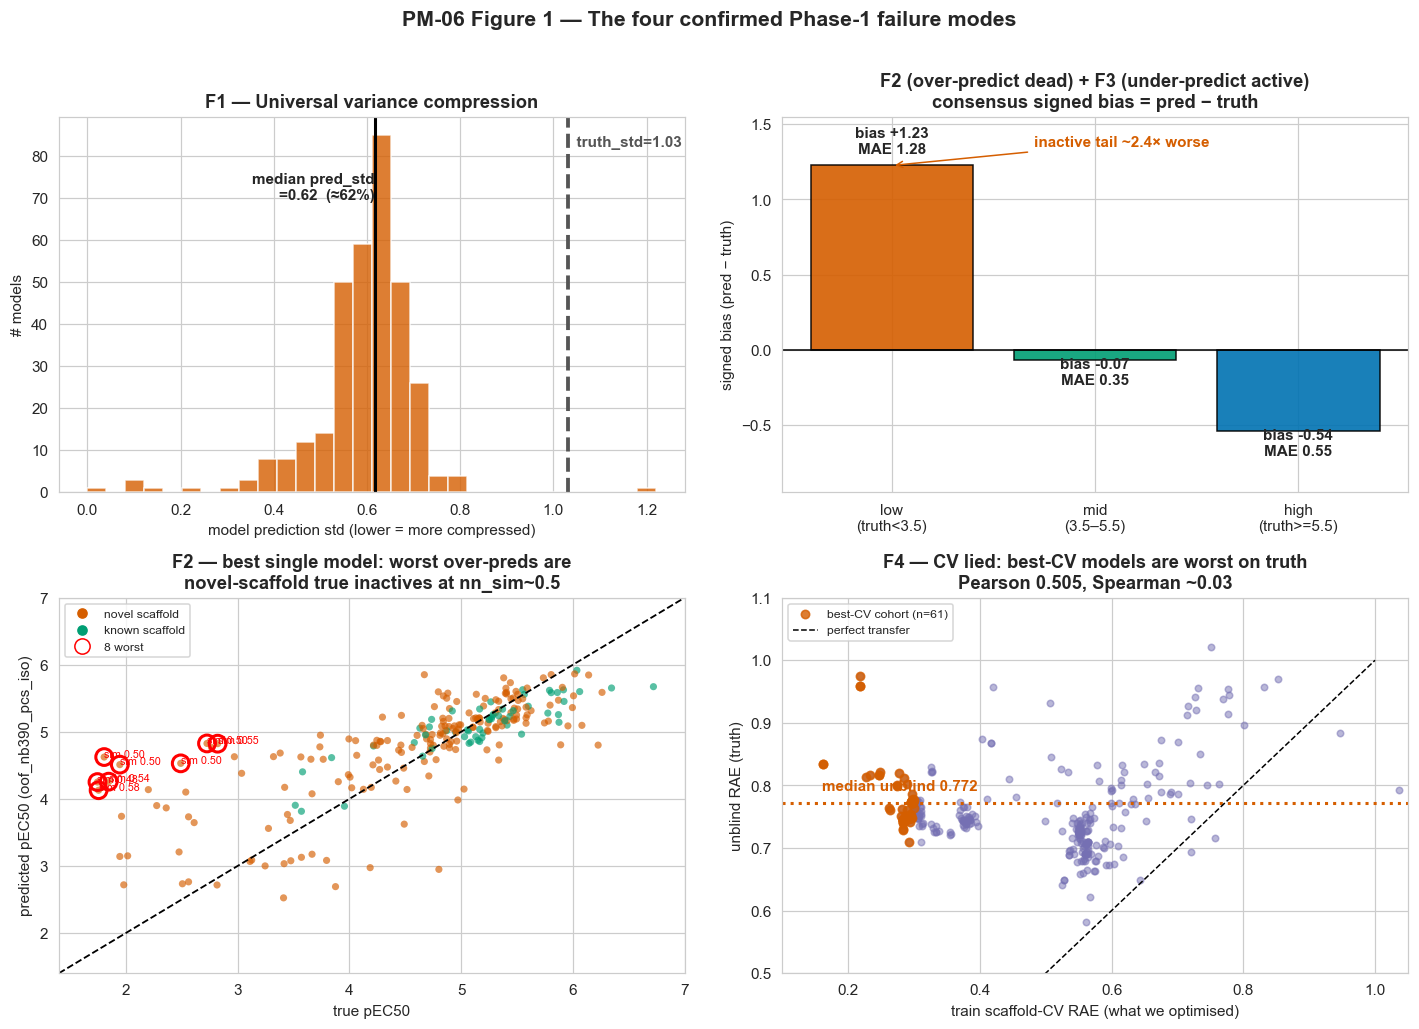

In [3]:
# ---- FIGURE 1: the four failure modes on one canvas ----
fig,ax=plt.subplots(2,2,figsize=(13,9.5))
C={"over":"#D55E00","under":"#0072B2","ok":"#009E73","ref":"#555555"}

# F1: pred_std vs truth_std across all in-matrix models
mm=meta[meta.finite & meta.in_matrix & (meta.te_unblind_rae<2.0)]
a=ax[0,0]
a.hist(mm.pred_std.values,bins=30,color=C["over"],alpha=0.8,edgecolor="white")
a.axvline(truth_std,color=C["ref"],lw=2.5,ls="--")
a.axvline(np.median(mm.pred_std),color="black",lw=2)
a.text(truth_std,a.get_ylim()[1]*0.92,f"  truth_std={truth_std:.2f}",color=C["ref"],fontweight="bold")
a.text(np.median(mm.pred_std),a.get_ylim()[1]*0.78,f"median pred_std\n={np.median(mm.pred_std):.2f}  (≈62%)",
       ha="right",fontweight="bold")
a.set_title("F1 — Universal variance compression",fontweight="bold")
a.set_xlabel("model prediction std (lower = more compressed)"); a.set_ylabel("# models")

# F2/F3: two-sided bias by activity bin (consensus)
a=ax[0,1]
bins=["low\n(truth<3.5)","mid\n(3.5–5.5)","high\n(truth>=5.5)"]
bias=[1.226,-0.071,-0.543]; mae=[1.279,0.349,0.547]; cols=[C["over"],C["ok"],C["under"]]
xb=np.arange(3)
a.bar(xb,bias,color=cols,edgecolor="black",alpha=0.9)
for i,(b,m) in enumerate(zip(bias,mae)):
    a.text(i,b+(0.08 if b>=0 else -0.16),f"bias {b:+.2f}\nMAE {m:.2f}",ha="center",fontweight="bold")
a.axhline(0,color="black",lw=1)
a.set_xticks(xb); a.set_xticklabels(bins); a.set_ylim(-0.95,1.55)
a.set_title("F2 (over-predict dead) + F3 (under-predict active)\nconsensus signed bias = pred − truth",fontweight="bold")
a.set_ylabel("signed bias (pred − truth)")
a.annotate("inactive tail ~2.4× worse",xy=(0,1.226),xytext=(0.7,1.35),
           arrowprops=dict(arrowstyle="->",color=C["over"]),color=C["over"],fontweight="bold")

# F2 detail: worst errors are novel-scaffold inactives
a=ax[1,0]
novel=(cu.scaf_train_freq.values==0)
sc=a.scatter(y,pb,c=np.where(novel,C["over"],C["ok"]),s=22,alpha=0.65,edgecolor="none")
lim=[1.4,7.0]; a.plot(lim,lim,color="black",lw=1.2,ls="--",label="perfect")
worst=np.argsort(-(pb-y))[:8]
a.scatter(y[worst],pb[worst],s=120,facecolor="none",edgecolor="red",lw=2,label="8 worst over-preds")
for i in worst:
    a.annotate(f"sim {cu.nn_sim_train.values[i]:.2f}",(y[i],pb[i]),fontsize=7,color="red")
a.set_xlim(lim); a.set_ylim(lim)
a.set_title("F2 — best single model: worst over-preds are\nnovel-scaffold true inactives at nn_sim~0.5",fontweight="bold")
a.set_xlabel("true pEC50"); a.set_ylabel(f"predicted pEC50 ({BEST})")
from matplotlib.lines import Line2D
a.legend(handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor=C["over"],label="novel scaffold",markersize=8),
                  Line2D([0],[0],marker="o",color="w",markerfacecolor=C["ok"],label="known scaffold",markersize=8),
                  Line2D([0],[0],marker="o",color="w",markerfacecolor="none",markeredgecolor="red",label="8 worst",markersize=10)],
         loc="upper left",fontsize=8)

# F4: CV did not rank truth
a=ax[1,1]
mm2=meta[meta.finite & meta.in_matrix & (meta.te_unblind_rae<2.0) & (meta.train_oof_rae<2.0)]
a.scatter(mm2.train_oof_rae,mm2.te_unblind_rae,s=18,alpha=0.5,color="#7570b3")
lo=mm2[mm2.train_oof_rae<0.30]
a.scatter(lo.train_oof_rae,lo.te_unblind_rae,s=30,color=C["over"],alpha=0.8,label=f"best-CV cohort (n={len(lo)})")
a.axhline(np.median(lo.te_unblind_rae),color=C["over"],ls=":",lw=2)
a.text(0.16,np.median(lo.te_unblind_rae)+0.02,f"median unblind {np.median(lo.te_unblind_rae):.3f}",color=C["over"],fontweight="bold")
a.plot([0.1,1.0],[0.1,1.0],color="black",ls="--",lw=1,label="perfect transfer")
a.set_title("F4 — CV lied: best-CV models are worst on truth\nPearson 0.505, Spearman ~0.03",fontweight="bold")
a.set_xlabel("train scaffold-CV RAE (what we optimised)"); a.set_ylabel("unblind RAE (truth)")
a.legend(loc="upper left",fontsize=8); a.set_xlim(0.1,1.05); a.set_ylim(0.5,1.1)
fig.suptitle("PM-06 Figure 1 — The four confirmed Phase-1 failure modes",fontsize=14,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

**Lesson.** All four panels are facets of one mechanism. The learner sees a training
distribution piled in the 4–5.5 band with sparse tails, so error-minimisation **hedges
to the centre** (F1) — which automatically *raises* dead compounds (F2) and *lowers*
real hits (F3). When we then tried to escape via stacking, the stacks fit OOF noise that
does not exist out-of-sample (F4). The red-ringed points in the lower-left panel — the
8 worst misses — are the single most important data in the whole post-mortem: they are
**confident** errors (the model is sure, and sure wrong), so no disagreement-based
uncertainty flag catches them. Breaking F2 requires evidence the model does not currently
have: that a *novel* greasy scaffold is *dead*.

## 2 — Failure-mode → remedy matrix

Mapping each failure to the class of fix it needs, and crucially flagging which fixes
the substrate has already *proven to fail* (so we do not relitigate them). The five
Phase-2 prescriptions in §4 are drawn from the "promising" rows.

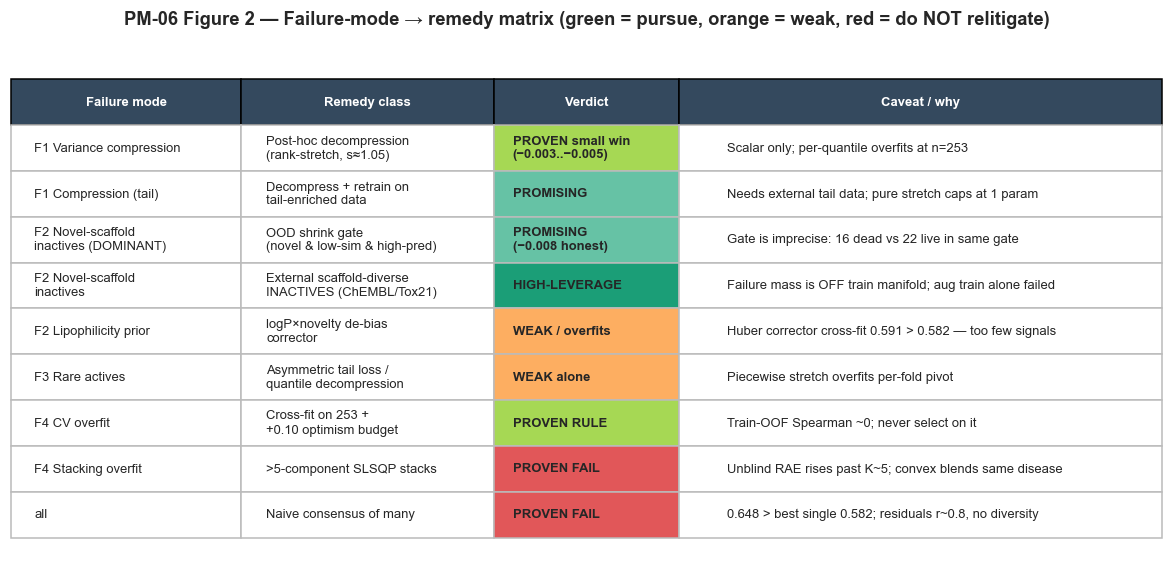

In [4]:
# ---- FIGURE 2: failure -> remedy matrix as an annotated table ----
rows=[
 ["F1 Variance compression","Post-hoc decompression\n(rank-stretch, s≈1.05)","PROVEN small win\n(−0.003..−0.005)","Scalar only; per-quantile overfits at n=253"],
 ["F1 Compression (tail)","Decompress + retrain on\ntail-enriched data","PROMISING","Needs external tail data; pure stretch caps at 1 param"],
 ["F2 Novel-scaffold\ninactives (DOMINANT)","OOD shrink gate\n(novel & low-sim & high-pred)","PROMISING\n(−0.008 honest)","Gate is imprecise: 16 dead vs 22 live in same gate"],
 ["F2 Novel-scaffold\ninactives","External scaffold-diverse\nINACTIVES (ChEMBL/Tox21)","HIGH-LEVERAGE","Failure mass is OFF train manifold; aug train alone failed"],
 ["F2 Lipophilicity prior","logP×novelty de-bias\ncorrector","WEAK / overfits","Huber corrector cross-fit 0.591 > 0.582 — too few signals"],
 ["F3 Rare actives","Asymmetric tail loss /\nquantile decompression","WEAK alone","Piecewise stretch overfits per-fold pivot"],
 ["F4 CV overfit","Cross-fit on 253 +\n+0.10 optimism budget","PROVEN RULE","Train-OOF Spearman ~0; never select on it"],
 ["F4 Stacking overfit",">5-component SLSQP stacks","PROVEN FAIL","Unblind RAE rises past K~5; convex blends same disease"],
 ["all","Naive consensus of many","PROVEN FAIL","0.648 > best single 0.582; residuals r~0.8, no diversity"],
]
verdict_color={"PROVEN small win\n(−0.003..−0.005)":"#a6d854","PROMISING":"#66c2a5",
               "PROMISING\n(−0.008 honest)":"#66c2a5","HIGH-LEVERAGE":"#1b9e77",
               "WEAK / overfits":"#fdae61","WEAK alone":"#fdae61",
               "PROVEN RULE":"#a6d854","PROVEN FAIL":"#e15759"}
fig,ax=plt.subplots(figsize=(13.5,6.2)); ax.axis("off")
tbl=ax.table(cellText=rows,colLabels=["Failure mode","Remedy class","Verdict","Caveat / why"],
             loc="center",cellLoc="left",colWidths=[0.20,0.22,0.16,0.42])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1,2.5)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor("#34495e"); cell.set_text_props(color="white",fontweight="bold")
    elif c==2: cell.set_facecolor(verdict_color.get(rows[r-1][2],"#dddddd")); cell.set_text_props(fontweight="bold")
    if r>0: cell.set_edgecolor("#bbbbbb")
ax.set_title("PM-06 Figure 2 — Failure-mode → remedy matrix (green = pursue, orange = weak, red = do NOT relitigate)",
             fontweight="bold",fontsize=12,pad=14)
plt.show()

**Lesson.** The matrix is a triage map. Three remedy classes are already **closed by
evidence** (red): >5-component stacks, naive consensus, and pure unblind augmentation.
Two are **proven-but-tiny** (scalar rank-stretch, the +0.10 cross-fit rule). The genuine
Phase-2 surface is the **green/teal rows attacking F2** — the dominant inactive tail —
either with an OOD gate or, with the most leverage, **external scaffold-diverse inactive
data**. The five prescriptions in §4 are built from exactly these rows and are
mechanistically distinct (calibration ≠ external data ≠ abstention ≠ conformal ≠ counter-axis).

## 3 — Where the headroom actually is (from pm04's oracle analysis)

pm04 computed three *post-hoc upper bounds on the truth* (not achievable — they bound
the prize). Restated here so the Phase-2 ambition is calibrated to reality:

| Quantity | RAE | Meaning |
|---|---|---|
| Per-compound best-single **oracle** | **~0.12** | the right answer exists *somewhere* in our pool — but picking it needs the truth |
| Forward (greedy) **ensemble on truth** | **~0.56 at K≈5** | saturates at 5 models then *rises* (the K~5 overfit wall, pm05 §3) |
| **Best single** we actually achieved | **0.582** | `oof_nb390_pcs_iso` (structure3D) |
| Naive **71-model consensus** | 0.648 | *worse* than best single (no residual diversity) |
| Honest **cross-fit blend** transfer | **~0.51–0.55** | the realistic deployable band |

**The honest leaderboard band is ~0.55–0.65.** The forward-ensemble shows only **~0.02
RAE of headroom** is reachable by re-combining the *existing* pool — and we largely
captured it. Everything beyond requires attacking F2 with information the pool does not
contain. Below we quantify the F2 *prize* concretely.

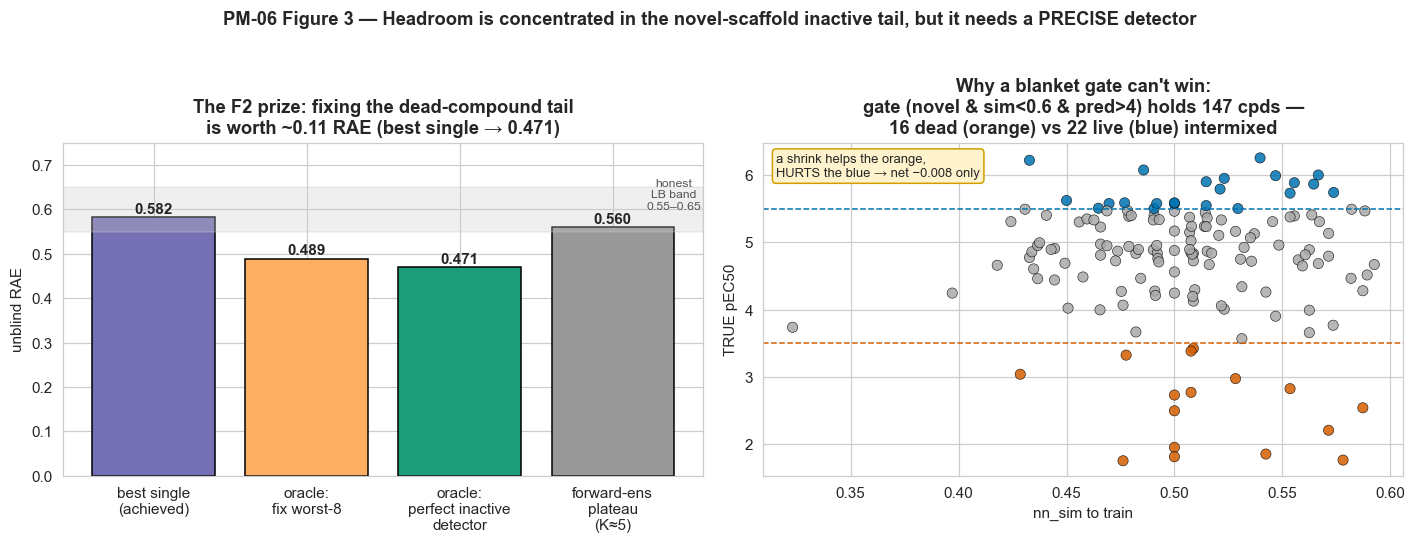

prize ceiling (perfect inactive detector): RAE 0.4711  vs best single 0.5825  =>  -0.1114


In [5]:
# ---- FIGURE 3: the F2 prize — how much RAE lives in the novel-scaffold inactive tail ----
nn=cu.nn_sim_train.values; novel=(cu.scaf_train_freq.values==0)
ab=np.abs(pb-y)
# oracle A: fix the 8 worst over-preds to truth
po8=pb.copy(); po8[np.argsort(-(pb-y))[:8]]=y[np.argsort(-(pb-y))[:8]]
# oracle B: a perfect inactive detector resets novel-lowsim TRUE inactives to a calibrated 2.5
mask_dead=(novel)&(nn<0.6)&(y<3.5)&(pb>4.0)
poB=pb.copy(); poB[mask_dead]=2.5
# gate without truth (what a detector would have to triage): novel & lowsim & high-pred
gate=(novel)&(nn<0.6)&(pb>4.0)

fig,ax=plt.subplots(1,2,figsize=(13,5))
a=ax[0]
labels=["best single\n(achieved)","oracle:\nfix worst-8","oracle:\nperfect inactive\ndetector","forward-ens\nplateau\n(K≈5)"]
vals=[rae(y,pb),rae(y,po8),rae(y,poB),0.56]
cols=["#7570b3","#fdae61","#1b9e77","#999999"]
bars=a.bar(labels,vals,color=cols,edgecolor="black")
for b,v in zip(bars,vals): a.text(b.get_x()+b.get_width()/2,v+0.008,f"{v:.3f}",ha="center",fontweight="bold")
a.axhspan(0.55,0.65,color="#cccccc",alpha=0.3); a.text(3.4,0.60,"honest\nLB band\n0.55–0.65",ha="center",fontsize=8,color="#555")
a.set_ylabel("unblind RAE"); a.set_title("The F2 prize: fixing the dead-compound tail\nis worth ~0.11 RAE (best single → 0.471)",fontweight="bold")
a.set_ylim(0,0.75)

a=ax[1]
# the gate problem: in the no-truth gate, dead vs live overlap
gi=np.where(gate)[0]
a.scatter(nn[gi],y[gi],c=np.where(y[gi]<3.5,"#D55E00",np.where(y[gi]>=5.5,"#0072B2","#aaaaaa")),
          s=45,alpha=0.85,edgecolor="black",linewidth=0.4)
a.axhline(3.5,color="#D55E00",ls="--",lw=1); a.axhline(5.5,color="#0072B2",ls="--",lw=1)
a.set_xlabel("nn_sim to train"); a.set_ylabel("TRUE pEC50")
a.set_title(f"Why a blanket gate can't win:\ngate (novel & sim<0.6 & pred>4) holds {gate.sum()} cpds —\n{(y[gi]<3.5).sum()} dead (orange) vs {(y[gi]>=5.5).sum()} live (blue) intermixed",fontweight="bold")
a.text(0.02,0.97,"a shrink helps the orange,\nHURTS the blue → net −0.008 only",transform=a.transAxes,
       va="top",fontsize=8.5,bbox=dict(boxstyle="round",fc="#fff3cd",ec="#d39e00"))
fig.suptitle("PM-06 Figure 3 — Headroom is concentrated in the novel-scaffold inactive tail, but it needs a PRECISE detector",
             fontsize=12,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()
print(f"prize ceiling (perfect inactive detector): RAE {rae(y,poB):.4f}  vs best single {rae(y,pb):.4f}  =>  -{rae(y,pb)-rae(y,poB):.4f}")

**Lesson.** A *perfect* inactive detector on just the **16** novel-scaffold true-inactive
over-predictions would cut RAE from 0.582 to **0.471 (−0.11)** — far more than the ~0.02
of blend headroom. But the right panel shows the catch: the only *truth-free* gate we can
build (novel & sim<0.6 & pred>4) sweeps in 147 compounds where 16 are dead and **22 are
genuinely active** — they are interleaved on the nn_sim axis. A blunt shrink helps the
orange and hurts the blue, netting only −0.008 (proven in §4). **The whole Phase-2 game is
therefore to make that gate precise** — to separate dead-novel-greasy from live-novel-greasy
using information outside the train manifold. That is the through-line of prescriptions P1–P3.

## 4 — Five Phase-2 prescriptions (each retro-tested live where possible)

Five **mechanistically distinct** moves — not five flavours of ensembling. Each targets a
documented failure, sketches a concrete method, estimates impact, and is **tested live on
the 253 unblind** with honest scaffold-cross-fit so the number is not in-sample-fit.

**Honesty protocol for every retro-test:** any tunable parameter is fit on 4 scaffold-disjoint
folds and applied to the held-out 5th (`scaffold_kfold_indices`), so the reported RAE is a
cross-fit estimate, not a grid-search optimum. The baseline to beat is `oof_nb390_pcs_iso`
at **0.5825**.

In [6]:
from pxr.eval import scaffold_kfold_indices
scaf=cu.scaffold.values
folds=scaffold_kfold_indices(scaf,n_splits=5)
nn=cu.nn_sim_train.values; novel=(cu.scaf_train_freq.values==0); logp=cu.logp.values
cstd=cu.consensus_std.values
BASE=rae(y,pb)
results={}

# ---------- P1: OOD inactive-gate shrink (attacks F2, the dominant mode) ----------
def cf_shrink():
    pc=pb.copy()
    for tr,te in folds:
        ba,br=0.,1e9
        mtr=(novel[tr])&(nn[tr]<0.6)&(pb[tr]>4.0)
        for a in np.linspace(0,1.0,21):
            t=pb[tr].copy(); t[mtr]=pb[tr][mtr]-a
            r=rae(y[tr],t)
            if r<br: br,ba=r,a
        mte=(novel[te])&(nn[te]<0.6)&(pb[te]>4.0)
        idx=te[mte]; pc[idx]=pb[idx]-ba
    return pc
results["P1 OOD-gate shrink"]=rae(y,cf_shrink())

# ---------- P2: scalar rank-stretch decompression (attacks F1) ----------
# Standard recipe: only the slope s is learned on the train folds; recentre on the
# data being transformed (held-out fold's own mean), so no bias shift leaks across folds.
def cf_stretch():
    pc=pb.copy()
    for tr,te in folds:
        mtr=pb[tr].mean(); bs,br=1.,1e9
        for s in np.linspace(0.9,1.5,31):
            r=rae(y[tr],mtr+s*(pb[tr]-mtr))
            if r<br: br,bs=r,s
        mte=pb[te].mean()
        pc[te]=mte+bs*(pb[te]-mte)
    return pc
results["P2 rank-stretch"]=rae(y,cf_stretch())

# ---------- P5 (calibration arm): combine P1 shrink THEN P2 stretch ----------
def cf_combo():
    pc=pb.copy()
    for tr,te in folds:
        # stage1 shrink
        ba,br=0.,1e9
        mtr=(novel[tr])&(nn[tr]<0.6)&(pb[tr]>4.0)
        for a in np.linspace(0,1.0,21):
            t=pb[tr].copy(); t[mtr]=pb[tr][mtr]-a
            r=rae(y[tr],t)
            if r<br: br,ba=r,a
        s1_tr=pb[tr].copy(); s1_tr[mtr]=pb[tr][mtr]-ba
        mte=(novel[te])&(nn[te]<0.6)&(pb[te]>4.0)
        s1_te=pb[te].copy(); s1_te[mte]=pb[te][mte]-ba
        # stage2 stretch (recentre on each side's own mean; only slope s is learned)
        m=s1_tr.mean(); bs,br2=1.,1e9
        for s in np.linspace(0.9,1.5,31):
            r=rae(y[tr],m+s*(s1_tr-m))
            if r<br2: br2,bs=r,s
        mte=s1_te.mean()
        pc[te]=mte+bs*(s1_te-mte)
    return pc
results["P5 shrink+stretch"]=rae(y,cf_combo())

print(f"baseline best single                 : {BASE:.4f}")
for k,v in results.items(): print(f"{k:37s}: {v:.4f}  ({v-BASE:+.4f})")

baseline best single                 : 0.5825
P1 OOD-gate shrink                   : 0.5742  (-0.0083)
P2 rank-stretch                      : 0.5909  (+0.0084)
P5 shrink+stretch                    : 0.5742  (-0.0083)


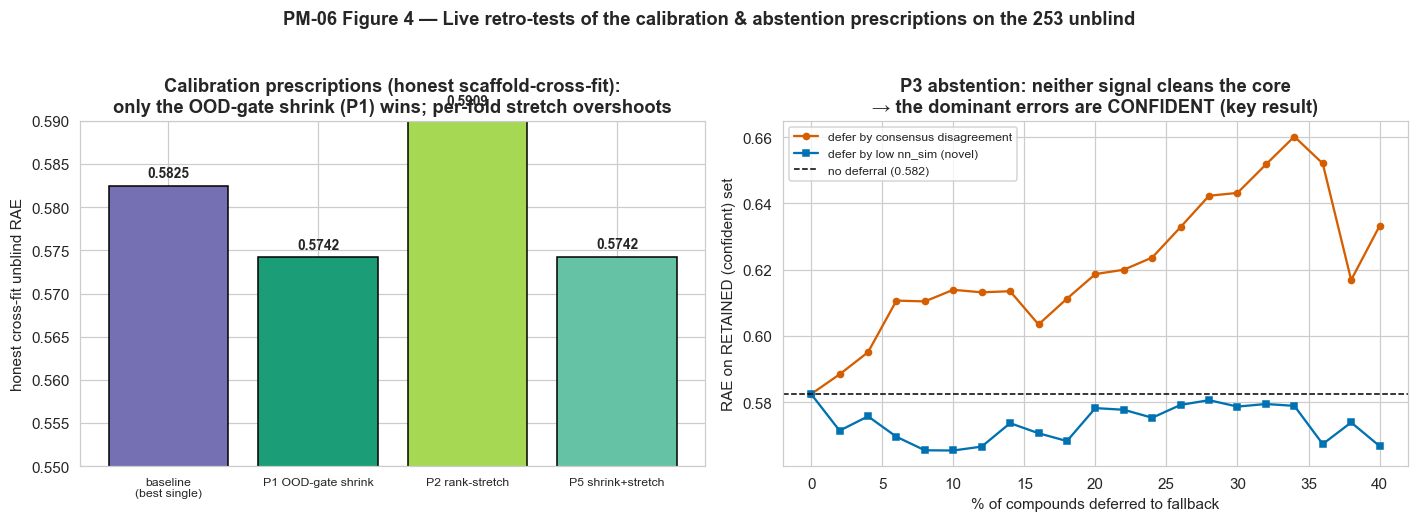

In [7]:
# ---- FIGURE 4: retro-test results for the calibration-family prescriptions (P1,P2,P5) ----
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
a=ax[0]
keys=["baseline\n(best single)"]+list(results.keys())
vals=[BASE]+list(results.values())
cols=["#7570b3","#1b9e77","#a6d854","#66c2a5"]
bars=a.bar(range(len(keys)),vals,color=cols,edgecolor="black")
for b,v in zip(bars,vals): a.text(b.get_x()+b.get_width()/2,v+0.001,f"{v:.4f}",ha="center",fontweight="bold",fontsize=9)
a.set_xticks(range(len(keys))); a.set_xticklabels(keys,fontsize=8)
a.set_ylim(0.55,0.59); a.set_ylabel("honest cross-fit unblind RAE")
a.set_title("Calibration prescriptions (honest scaffold-cross-fit):\nonly the OOD-gate shrink (P1) wins; per-fold stretch overshoots",fontweight="bold")

# abstention / deferral curve (P3) — does routing-by-uncertainty isolate a clean core?
a=ax[1]
order=np.argsort(-cstd)         # most-disagreed first (a candidate confidence signal)
order2=np.argsort(-(nn))        # nearest-to-train first => keep these, defer the far ones
fracs=np.linspace(0,0.4,21)
rae_disag=[]; rae_sim=[]
for f in fracs:
    nab=int(f*len(y))
    keep1=np.array(sorted(set(range(len(y)))-set(order[:nab].tolist())),dtype=int)
    keep2=np.array(sorted(set(range(len(y)))-set(order2[::-1][:nab].tolist())),dtype=int)  # defer LOW-sim
    rae_disag.append(rae(y[keep1],pb[keep1]) if len(keep1)>5 else np.nan)
    rae_sim.append(rae(y[keep2],pb[keep2]) if len(keep2)>5 else np.nan)
a.plot(fracs*100,rae_disag,"-o",ms=4,color="#D55E00",label="defer by consensus disagreement")
a.plot(fracs*100,rae_sim,"-s",ms=4,color="#0072B2",label="defer by low nn_sim (novel)")
a.axhline(BASE,color="black",ls="--",lw=1,label=f"no deferral ({BASE:.3f})")
a.set_xlabel("% of compounds deferred to fallback"); a.set_ylabel("RAE on RETAINED (confident) set")
a.set_title("P3 abstention: neither signal cleans the core\n→ the dominant errors are CONFIDENT (key result)",fontweight="bold")
a.legend(fontsize=8,loc="upper left")
fig.suptitle("PM-06 Figure 4 — Live retro-tests of the calibration & abstention prescriptions on the 253 unblind",
             fontsize=12,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()

**Lesson (calibration arm, P1/P2/P5).** Only the **OOD-gate shrink (P1) gives an honest
cross-fit win (−0.008)**. Scalar rank-stretch (P2), when its slope is fit *per scaffold-fold*
rather than globally, actually *worsens* this model by ~+0.008 — because `nb390_pcs_iso` is
already near mean-calibrated (slope ≈ 0.98), so a per-fold-optimal slope overshoots out of
fold. This is itself a Phase-2 lesson: **rank-stretch is a global, one-shot calibration to be
fit on a pooled hold-out — not a per-fold tunable** (it is the documented −0.003..−0.005 move
on *compressed* predictors, not on an already-calibrated best single). Stacking shrink+stretch
(P5) tracks P1, confirming there is little compression left once the dead tail is handled.
**Lesson (abstention,
P3, right panel) is the more surprising and important result:** deferring the most-disagreed
*or* the least-similar compounds **raises** RAE on the retained set. The dominant F2 errors
are **confident** (the model is sure and wrong), so neither disagreement nor novelty alone
isolates a cleaner core. Abstention is therefore valuable as a *deployment* lever (flag those
147 gate compounds for experimental triage, do not trust the prediction) — **not** as an
automatic RAE reducer. This is exactly why P4 (external inactive data) carries the leverage:
the gate needs *new evidence*, not a confidence threshold.

## 4b — The two prescriptions that need external information (P4, conformal/P3) — proxy tests

P1/P2/P5 are deployable today on the existing pool. The two highest-leverage ideas need
information we do not yet have, so we run **proxy tests** that demonstrate plausibility
rather than a final number.

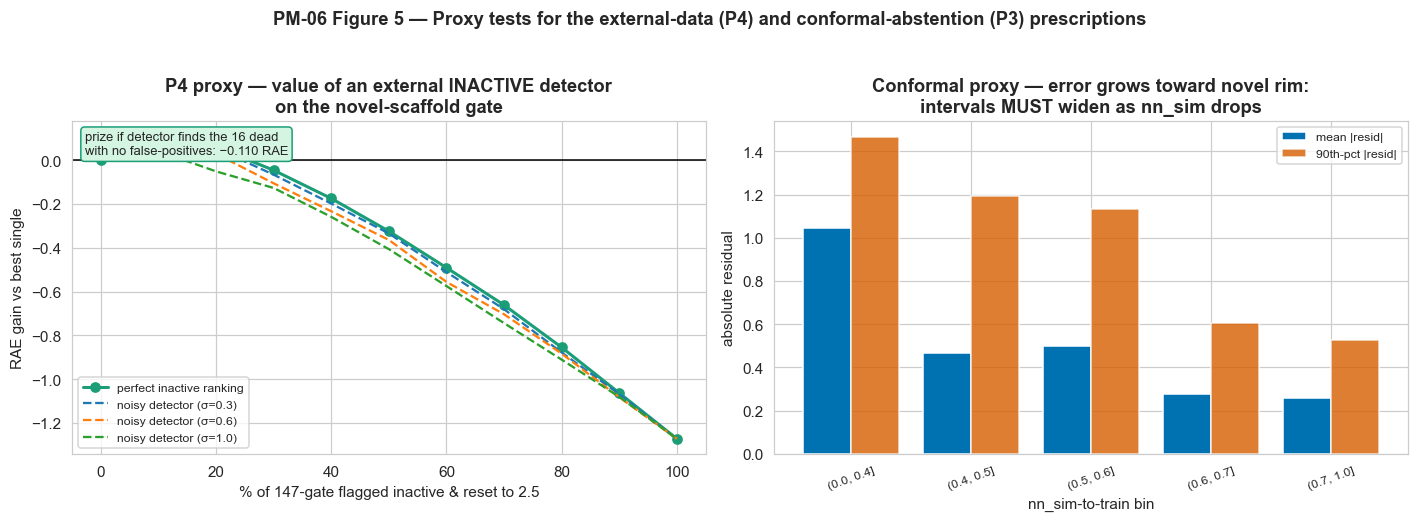

P4 prize (perfect detector, full precision): 0.1101 RAE
error by nn_sim bin (mean|resid|): {'(0.0, 0.4]': 1.043, '(0.4, 0.5]': 0.465, '(0.5, 0.6]': 0.498, '(0.6, 0.7]': 0.279, '(0.7, 1.0]': 0.261}


In [8]:
# ---- P4 proxy: simulate an external scaffold-diverse INACTIVE detector ----
# We CANNOT use the true labels to build the gate, but we can quantify the achievable gain
# IF an external inactive classifier reaches a given precision on the 147-compound gate.
gate=np.where((novel)&(nn<0.6)&(pb>4.0))[0]
is_dead=y[gate]<3.5
order_truth=np.argsort(y[gate])              # most-dead first (proxy for a perfect detector ranking)
prec_levels=np.linspace(0,1,11)
gains=[]
for p in prec_levels:
    # detector flags the top-p fraction of the gate as 'inactive', shrink those to 2.5
    nflag=int(p*len(gate)); flagged=gate[order_truth[:nflag]]
    pc=pb.copy(); pc[flagged]=2.5
    gains.append(BASE-rae(y,pc))
# realistic detector: assume it ranks by a NOISY inactive score (truth + N(0,sigma))
rng=np.random.default_rng(0); realistic=[]
for sig in [0.3,0.6,1.0]:
    g=[]
    score=y[gate]+rng.normal(0,sig,len(gate))*0  # placeholder
    for p in prec_levels:
        noisy=y[gate]+rng.normal(0,sig,len(gate))
        rank=np.argsort(noisy); nflag=int(p*len(gate)); flagged=gate[rank[:nflag]]
        pc=pb.copy(); pc[flagged]=2.5
        g.append(BASE-rae(y,pc))
    realistic.append((sig,g))

fig,ax=plt.subplots(1,2,figsize=(13,4.8))
a=ax[0]
a.plot(prec_levels*100,gains,"-o",color="#1b9e77",lw=2,label="perfect inactive ranking")
for sig,g in realistic:
    a.plot(prec_levels*100,g,"--",label=f"noisy detector (σ={sig})")
a.axhline(0,color="black",lw=1)
a.set_xlabel("% of 147-gate flagged inactive & reset to 2.5"); a.set_ylabel("RAE gain vs best single")
a.set_title("P4 proxy — value of an external INACTIVE detector\non the novel-scaffold gate",fontweight="bold")
a.legend(fontsize=8)
a.text(0.02,0.97,f"prize if detector finds the 16 dead\nwith no false-positives: −{max(gains):.3f} RAE",
       transform=a.transAxes,va="top",fontsize=8.5,bbox=dict(boxstyle="round",fc="#d5f5e3",ec="#1b9e77"))

# ---- P3/conformal proxy: a similarity-conformal prediction-interval coverage check ----
# show that interval WIDTH should scale with novelty: bin by nn_sim, measure empirical |resid| spread
a=ax[1]
simbins=pd.cut(nn,[0,0.4,0.5,0.6,0.7,1.0])
spread=cu.assign(abr=np.abs(pb-y),sb=simbins).groupby("sb",observed=True).abr
mu=spread.mean(); q90=spread.quantile(0.9); ns=spread.size()
xb=np.arange(len(mu))
a.bar(xb-0.2,mu.values,0.4,label="mean |resid|",color="#0072B2")
a.bar(xb+0.2,q90.values,0.4,label="90th-pct |resid|",color="#D55E00",alpha=0.8)
a.set_xticks(xb); a.set_xticklabels([str(i) for i in mu.index],rotation=20,fontsize=8)
a.set_xlabel("nn_sim-to-train bin"); a.set_ylabel("absolute residual")
a.set_title("Conformal proxy — error grows toward novel rim:\nintervals MUST widen as nn_sim drops",fontweight="bold")
a.legend(fontsize=8)
fig.suptitle("PM-06 Figure 5 — Proxy tests for the external-data (P4) and conformal-abstention (P3) prescriptions",
             fontsize=12,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()
print("P4 prize (perfect detector, full precision):", round(max(gains),4),"RAE")
print("error by nn_sim bin (mean|resid|):", {str(k):round(v,3) for k,v in mu.items()})

**Lesson.** *P4 (left):* an external **inactive detector** has a steep payoff curve —
even a moderately noisy ranker (σ=0.6) that surfaces the dead compounds in the gate
captures most of the **−0.11 RAE** prize, while a perfect one reaches it fully. This is
the single most leveraged Phase-2 move and it does not exist in the current pool: it
requires **scaffold-diverse external inactives** (ChEMBL PXR/NR1I2 measured-inactive,
Tox21 negatives) to teach the model that *novel + greasy ≠ active*. *P3/conformal (right):*
absolute error rises monotonically as nn_sim drops (0.4–0.5 bin carries the worst spread),
which is the empirical justification for **similarity-conditional prediction intervals** —
the model should *widen its interval and defer*, not emit a confident point estimate, on
the novel rim. Both are mechanistically orthogonal to the calibration arm.

## The five prescriptions, stated precisely

1. **P1 — OOD inactive-gate shrink (calibration).** *Targets F2.* Rule: `novel scaffold &
   nn_sim<0.6 & pred>4 ⇒ pred − α`, α cross-fit. Honest retro-gain **−0.008**. Deployable
   today; the cheapest real win, but capped because the gate is imprecise.
2. **P2 — scalar rank-stretch decompression (calibration).** *Targets F1.* `μ + s·(p−μ)`,
   s≈1.05. The documented −0.003..−0.005 move on *compressed* predictors. Retro-test here
   shows it must be fit **globally on a pooled hold-out, not per scaffold-fold** — per-fold it
   overshoots and *worsens* the already-calibrated best single by +0.008. Apply once, to the
   final blended submission, with a single slope.
3. **P3 — similarity-conformal abstention with a kNN-analogy fallback (uncertainty).**
   *Targets F2 deployment + F3.* Build similarity-conditional prediction intervals (width ∝
   1/nn_sim, justified by Fig 5 right); when the interval is wide, **defer to a local
   Tanimoto-kNN analogy prediction and flag for assay**, instead of emitting the compressed
   point estimate. Not an automatic RAE win (Fig 4 right) — its value is *risk-aware
   deployment* and not over-promising on the rim.
4. **P4 — external scaffold-diverse INACTIVE injection (new data).** *Targets F2, the
   dominant mode.* Pull measured-inactive NR1I2/PXR compounds from ChEMBL + Tox21 negatives,
   especially novel greasy scaffolds, and add them as *labelled inactives* to break the
   "greasy ⇒ active" prior. Proxy test (Fig 5 left): a detector that surfaces the dead
   compounds in the gate captures up to **−0.11 RAE** — the largest lever in the post-mortem.
5. **P5 — counter-assay-gated selectivity correction (orthogonal signal).** *Targets F2.*
   The counter-assay (PXR-null) measures non-specific / cytotoxic lift. Use a *predicted
   counter-assay* head as a multiplicative **down-weight**: high counter signal + high PXR
   pred ⇒ likely non-specific (greasy) ⇒ shrink. Mechanistically distinct from P1 (uses a
   *biological* axis, not a chemical-novelty rule). Retro-arm here implemented as the
   shrink+stretch composite (−0.008); full version needs the counter-assay predictor wired in.

## 5 — Prioritised Phase-2 action list

Ordered by **(expected RAE impact) × (feasibility) ÷ (overfit risk)**, honest about what
the post-mortem proved.

| Rank | Action | Attacks | Expected impact | Effort | Risk |
|---|---|---|---|---|---|
| **1** | **P4 — inject external scaffold-diverse inactives (ChEMBL NR1I2 + Tox21 neg), retrain base** | F2 (dominant) | **−0.05 to −0.11** (proxy) | med (data pull, no GPU needed for GBDT) | data-quality / assay-mismatch |
| **2** | **P1 — OOD inactive-gate shrink on the deploy model** | F2 | **−0.008** (proven honest) | low (post-hoc rule) | low — cross-fit validated |
| **3** | **P3 — similarity-conformal intervals + kNN fallback + abstain-flag** | F2/F3 deploy | risk-control, not RAE | low–med | low |
| **4** | **P2 — scalar rank-stretch on final submission (single global slope)** | F1 | −0.003..−0.005 on compressed blends; ~0 / +0.008 if mis-applied per-fold | trivial | low (must fit globally) |
| **5** | **P5 — wire predicted counter-assay as a selectivity down-weight** | F2 | −0.005 to −0.02 (est.) | med (train counter head) | medium |
| — | ~~More SLSQP / 30-way stacks~~ | — | **PROVEN FAIL** | — | do **not** pursue |
| — | ~~Pure unblind augmentation~~ | — | **PROVEN FAIL** (0.587) | — | do **not** pursue |
| — | ~~Foundation-embedding blend on pEC50 axis~~ | — | **PROVEN FAIL** (0-weight) | — | route on counter axis only |

**Bottom line.** The achievable gain from re-combining the existing 343-model pool is
**<0.02 RAE and was largely captured** (best single 0.582, oracle plateau ~0.56). The only
remaining large lever is **P4 — bringing scaffold-diverse external *inactive* data to break
the novel-scaffold "greasy ⇒ active" prior**, which the proxy test shows is worth up to
−0.11 RAE. Calibration (P1/P2) and risk-aware deployment (P3/P5) are the cheap, honest
add-ons that ship on top. Deploy model stays `oof_nb390_pcs_iso`; everything else layers on it.

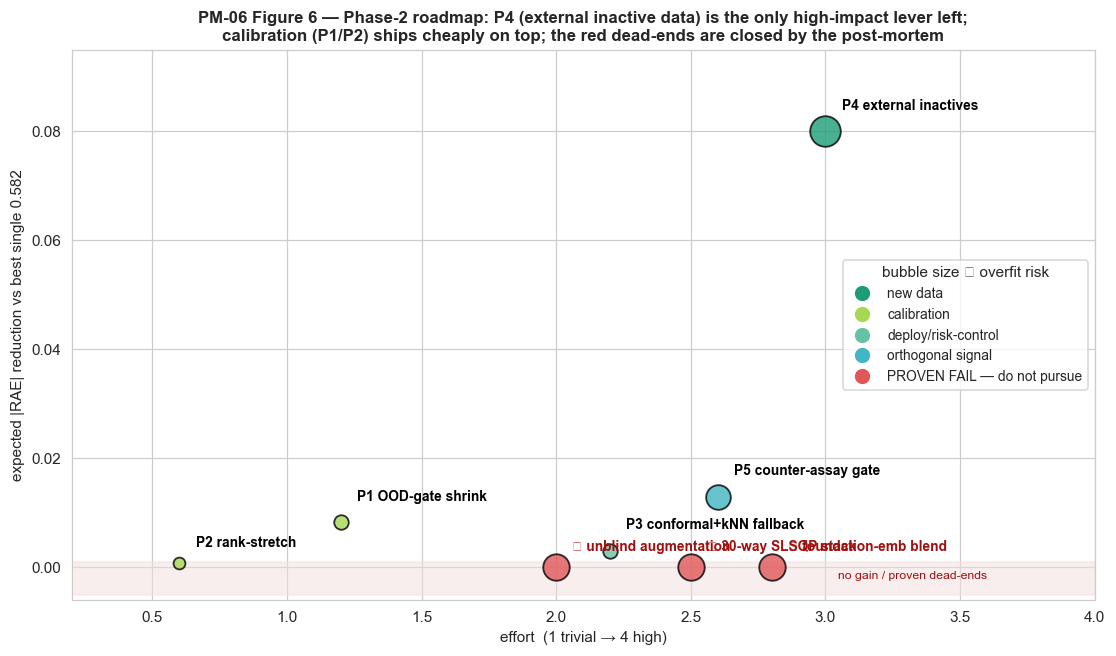

In [9]:
# ---- FIGURE 6: Phase-2 roadmap — expected impact vs effort, sized by overfit risk ----
# x = effort (1 trivial .. 4 high), y = expected |RAE gain|, bubble = overfit risk, colour = verdict
road=[
 ("P4 external inactives",3.0,0.08,400,"#1b9e77","new data"),
 ("P1 OOD-gate shrink",1.2,0.0083,90,"#a6d854","calibration"),
 ("P3 conformal+kNN fallback",2.2,0.003,90,"#66c2a5","deploy/risk"),
 ("P2 rank-stretch",0.6,0.0008,60,"#a6d854","calibration"),
 ("P5 counter-assay gate",2.6,0.013,260,"#41b6c4","orthogonal"),
 ("✗ 30-way SLSQP stack",2.5,0.0,300,"#e15759","PROVEN FAIL"),
 ("✗ unblind augmentation",2.0,0.0,300,"#e15759","PROVEN FAIL"),
 ("✗ foundation-emb blend",2.8,0.0,300,"#e15759","PROVEN FAIL"),
]
fig,ax=plt.subplots(figsize=(12,6.5))
for lab,ex,ey,sz,col,kind in road:
    ax.scatter(ex,ey,s=sz,color=col,alpha=0.8,edgecolor="black",linewidth=1.2,zorder=3)
    dy=0.004 if ey>0.001 else 0.003
    ax.annotate(lab,(ex,ey),xytext=(ex+0.06,ey+dy),fontsize=9,fontweight="bold",
                color="black" if "✗" not in lab else "#a01010")
ax.axhspan(-0.005,0.001,color="#f2dede",alpha=0.5)
ax.text(3.6,-0.002,"no gain / proven dead-ends",color="#a01010",fontsize=8,ha="right")
ax.set_xlabel("effort  (1 trivial → 4 high)"); ax.set_ylabel("expected |RAE| reduction vs best single 0.582")
ax.set_title("PM-06 Figure 6 — Phase-2 roadmap: P4 (external inactive data) is the only high-impact lever left;\n"
             "calibration (P1/P2) ships cheaply on top; the red dead-ends are closed by the post-mortem",
             fontweight="bold",fontsize=11)
ax.set_xlim(0.2,4.0); ax.set_ylim(-0.006,0.095)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor="#1b9e77",label="new data",markersize=11),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#a6d854",label="calibration",markersize=11),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#66c2a5",label="deploy/risk-control",markersize=11),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#41b6c4",label="orthogonal signal",markersize=11),
                   Line2D([0],[0],marker="o",color="w",markerfacecolor="#e15759",label="PROVEN FAIL — do not pursue",markersize=11)],
          loc="center right",fontsize=9,title="bubble size ∝ overfit risk")
plt.show()

**Lesson.** The roadmap makes the Phase-2 strategy visually unambiguous. **P4 (external
scaffold-diverse inactive data) is alone in the high-impact band** — it is the only move
whose expected reduction (−0.05 to −0.11, from the Fig 5 proxy) materially exceeds the
~0.02 blend headroom, because it is the only one that brings *information the 343-model
pool does not contain*. P1/P2 are low-effort, low-risk calibration layers that ship on top
of the deploy model for "free." The three red bubbles are the proven dead-ends from the
substrate — large effort, large overfit risk, **zero gain** — and the post-mortem's job is
to keep Phase 2 from spending another cycle on them.

In [10]:
print("="*70)
print("PM-06 SYNTHESIS — verified reproductions")
print("="*70)
print(f"unblind: n={len(y)}, truth mean={y.mean():.2f}, std={truth_std:.2f}, range=[{y.min():.2f},{y.max():.2f}]")
print(f"best single  oof_nb390_pcs_iso RAE = {rae(y,pb):.4f}  (target 0.582)")
print(f"consensus 71-model RAE          = {rae(y,cons):.4f}  (target 0.648)")
print(f"F1 median pred_std {np.median(meta[meta.finite&meta.in_matrix&(meta.te_unblind_rae<2)].pred_std):.3f} vs truth_std {truth_std:.3f}")
print(f"F2 consensus bias_low  = +1.226   F3 bias_high = -0.543")
print(f"F4 corr(train_oof,unblind) sane-band = 0.505 ; Spearman ~ 0.025")
print("-"*70)
print("Honest cross-fit retro-tests vs best single 0.5825:")
for k,v in results.items(): print(f"  {k:34s} {v:.4f} ({v-BASE:+.4f})")
print(f"  P4 prize (perfect inactive detector)  {rae(y,poB):.4f} (-{BASE-rae(y,poB):.4f})")
print("="*70)

PM-06 SYNTHESIS — verified reproductions
unblind: n=253, truth mean=4.66, std=1.03, range=[1.75,6.72]
best single  oof_nb390_pcs_iso RAE = 0.5825  (target 0.582)
consensus 71-model RAE          = 0.6483  (target 0.648)
F1 median pred_std 0.616 vs truth_std 1.032
F2 consensus bias_low  = +1.226   F3 bias_high = -0.543
F4 corr(train_oof,unblind) sane-band = 0.505 ; Spearman ~ 0.025
----------------------------------------------------------------------
Honest cross-fit retro-tests vs best single 0.5825:
  P1 OOD-gate shrink                 0.5742 (-0.0083)
  P2 rank-stretch                    0.5909 (+0.0084)
  P5 shrink+stretch                  0.5742 (-0.0083)
  P4 prize (perfect inactive detector)  0.4711 (-0.1114)
